<a href="https://colab.research.google.com/github/pallavi-vadlakonda/Student-Management-System-c/blob/main/DS_mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [2]:
#Load the dataset
df = pd.read_csv("/content/Titanic-Dataset.csv")

print(df.head(),"\n")
print(df.shape,"\n")
# print("\n")
print(df.info())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S   



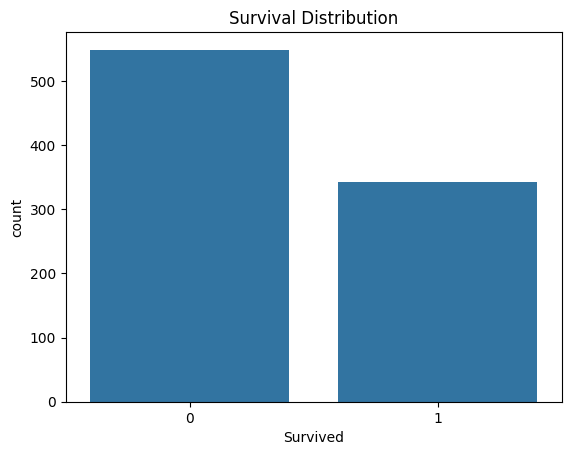

In [3]:
#Survival Distribution
sns.countplot(x='Survived', data=df)
plt.title("Survival Distribution")
plt.show()

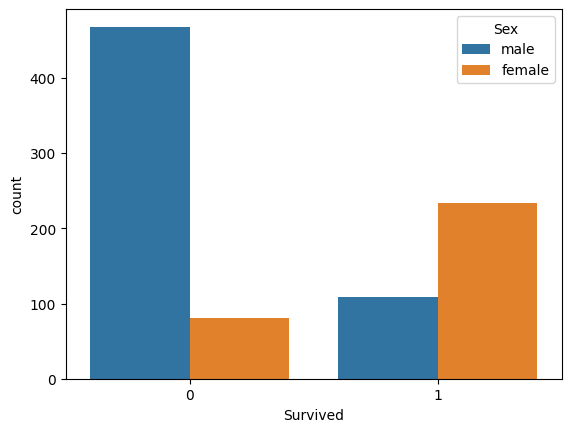

In [4]:
#Survival by Gender
sns.countplot(x='Survived', hue='Sex', data=df)
plt.show()

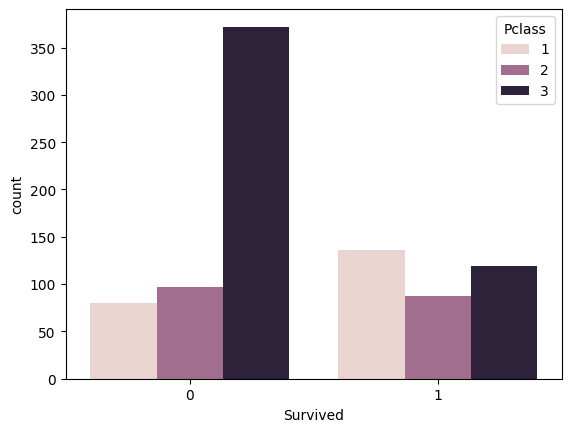

In [6]:
#Survival by Passenger Class
sns.countplot(x='Survived', hue='Pclass', data=df)
plt.show()

In [7]:
#Missing Values
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [8]:
#Handle Missing Values
df['Age']= df['Age'].fillna(df['Age'].median())
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

In [9]:
#Remove Unnecessary Columns
df.drop(
    ['PassengerId', 'Name', 'Ticket', 'Cabin'],
    axis=1,
    inplace=True
)

In [12]:
#Separate Features and Target
X = df.drop('Survived', axis=1)
y = df['Survived']

In [13]:
#Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [15]:
#Create Random Forest Model
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Apply one-hot encoding to X_train and X_test
# This should ideally be done on the full dataset X before splitting,
# but is placed here to adhere to the constraint of modifying only this cell.
X_train_encoded = pd.get_dummies(X_train, columns=['Sex', 'Embarked'], drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=['Sex', 'Embarked'], drop_first=True)

# Align columns - crucial for consistent feature sets between train and test
# Get all unique columns from both encoded datasets
all_cols = list(set(X_train_encoded.columns) | set(X_test_encoded.columns))

# Reindex both DataFrames to include all columns, filling missing with 0
X_train_encoded = X_train_encoded.reindex(columns=all_cols, fill_value=0)
X_test_encoded = X_test_encoded.reindex(columns=all_cols, fill_value=0)

# Ensure the column order is consistent (e.g., based on X_train_encoded)
X_test_encoded = X_test_encoded[X_train_encoded.columns]

#Train model
model.fit(X_train_encoded, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [19]:
#Model Prediction
y_pred = model.predict(X_test_encoded)
print(y_pred)
print(y_test)

[0 0 0 1 0 1 1 0 1 1 1 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 1 1 0 0 1
 1 1 0 0 0 0 0 0 0 1 0 0 0 1 1 0 1 0 1 0 1 1 0 0 1 1 0 0 1 0 0 0 1 1 1 1 1
 0 0 1 1 1 1 0 1 1 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 1 0 0 1 1
 0 1 1 0 0 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 0 0 1 1 0 1 0 0 0 0 1 1 0 0 1 0 1
 1 0 0 0 0 1 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 0 1 1 1 0 0 0 1 1]
709    1
439    0
840    0
720    1
39     1
      ..
433    0
773    0
25     1
84     1
10     1
Name: Survived, Length: 179, dtype: int64


In [20]:
#Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8044692737430168


In [23]:
from sklearn.linear_model import LogisticRegression

model1= LogisticRegression(max_iter=1000)
model1.fit(X_train_encoded, y_train)
y_pred1= model1.predict(X_test_encoded)
print("Accuracy:", accuracy_score(y_test, y_pred1))

Accuracy: 0.8100558659217877


In [27]:
from sklearn.neighbors import KNeighborsClassifier

model2 = KNeighborsClassifier(n_neighbors=5)
model2.fit(X_train_encoded, y_train)
y_pred2 = model2.predict(X_test_encoded)
print("Accuracy:", accuracy_score(y_test, y_pred2))

Accuracy: 0.6983240223463687


In [29]:
from sklearn.tree import DecisionTreeClassifier

mode13 = DecisionTreeClassifier(random_state=42)
mode13.fit(X_train_encoded, y_train)
y_pred3 = mode13.predict(X_test_encoded)
print("Accuracy:", accuracy_score(y_test, y_pred3))

Accuracy: 0.7821229050279329


In [33]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv("Titanic-Dataset.csv")

# Fill missing values
df['Age']=df['Age'].fillna(df['Age'].median())
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop unnecessary columns
df.drop(
    ['PassengerId', 'Name', 'Ticket', 'Cabin'],
    axis=1,
    inplace=True
)

# One-hot encoding
df = pd.get_dummies(
    df,
    columns=['Sex', 'Embarked'],
    drop_first=True
)

# Features and target
X = df.drop('Survived', axis=1)
y = df['Survived']

# Split data
x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Train model
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(x_train, y_train)

# Predictions
y_pred =model.predict(x_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8100558659217877
